## Age–Gender Classification with Keras Functional API

### Introduction
In the notebook **functional api practicals**, we are exploring how to build a **multi-output neural network** using the Keras Functional API.  
The focus is on practical examples that demonstrate how to classify:
- **Age group** (multi-class classification)
- **Gender** (binary classification)


In [1]:
import os
import numpy as np, pandas as pd
from keras.preprocessing.image import ImageDataGenerator

In [2]:
folder_path=r"C:\Users\rauna\codes\datasets\UTKFace"


In [3]:
age =[]
gender=[]
img_path=[]
for file in os.listdir(folder_path):
    age.append(int(file.split('_')[0]))
    gender.append(int(file.split("_")[1]))
    img_path.append(file)

In [4]:
len(age)

23708

In [5]:
df = pd.DataFrame({'age':age,'gender':gender,'img':img_path})
df

,age,gender,img
0,100,0,100_0_0_20170112213500903.jpg.chip.jpg
1,100,0,100_0_0_20170112215240346.jpg.chip.jpg
2,100,1,100_1_0_20170110183726390.jpg.chip.jpg
3,100,1,100_1_0_20170112213001988.jpg.chip.jpg
4,100,1,100_1_0_20170112213303693.jpg.chip.jpg
...,...,...,...
23703,9,1,9_1_3_20161220222856346.jpg.chip.jpg
23704,9,1,9_1_3_20170104222949455.jpg.chip.jpg
23705,9,1,9_1_4_20170103200637399.jpg.chip.jpg
23706,9,1,9_1_4_20170103200814791.jpg.chip.jpg


In [6]:
train_df = df.sample(frac=1,random_state=0).iloc[:20000]
test_df = df.sample(frac=1,random_state=0).iloc[20000:]

In [7]:
train_datagen = ImageDataGenerator(rescale=1./255,
                                   rotation_range=30,
                                   width_shift_range=0.2,
                                   height_shift_range=0.2,
                                   shear_range=0.2,
                                   zoom_range=0.2,
                                   horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1./255)


In [8]:
train_gen = train_datagen.flow_from_dataframe(train_df,
                                              folder_path,
                                              x_col="img",
                                              y_col=["age",'gender'],
                                              target_size=(200,200),
                                              class_mode="multi_output")
test_gen = test_datagen.flow_from_dataframe(test_df,
                                              folder_path,
                                              x_col="img",
                                              y_col=["age",'gender'],
                                              target_size=(200,200),
                                              class_mode="multi_output")


Found 20000 validated image filenames.
Found 3708 validated image filenames.


In [9]:
from keras.applications.vgg16 import VGG16
from keras.layers import *
from keras.models import Model

In [10]:
vggnet= VGG16(include_top=False, input_shape=(200,200,3))

In [11]:
vggnet.trainable = False

output = vggnet.layers[-1].output

flatten = Flatten()(output)

Dense1 = Dense(512,activation="relu")(flatten)
Dense2 = Dense(512,activation='relu')(flatten)

Dense3 = Dense(512,activation="relu")(Dense1)
Dense4 = Dense(512,activation='relu')(Dense2)

output1 = Dense(1,activation="linear",name = "age")(Dense3)
output2 = Dense(1, activation="sigmoid",name = "gender")(Dense4)

In [12]:
model = Model(inputs = vggnet.input, outputs = [output1,output2])

In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 200,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 200, 200,  │      1,792 │ input_layer[0][0] │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 200, 200,  │     36,928 │ block1_conv1[0][… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_pool         │ (None, 100, 100,  │          0 │ block1_conv2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv1        │ (None, 100, 100,  │     73,856 │ block1_pool[0][0] │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_conv2        │ (None, 100, 100,  │    147,584 │ block2_conv1[0][… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 50, 50,    │          0 │ block2_conv2[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv1        │ (None, 50, 50,    │    295,168 │ block2_pool[0][0] │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv2        │ (None, 50, 50,    │    590,080 │ block3_conv1[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_conv3        │ (None, 50, 50,    │    590,080 │ block3_conv2[0][… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_pool         │ (None, 25, 25,    │          0 │ block3_conv3[0][… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv1        │ (None, 25, 25,    │  1,180,160 │ block3_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv2        │ (None, 25, 25,    │  2,359,808 │ block4_conv1[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_conv3        │ (None, 25, 25,    │  2,359,808 │ block4_conv2[0][… │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block4_pool         │ (None, 12, 12,    │          0 │ block4_conv3[0][… │
│ (MaxPooling2D)      │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv1        │ (None, 12, 12,    │  2,359,808 │ block4_pool[0][0] │
│ (Conv2D)            │ 512)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block5_conv2        │ (None, 12, 12,    │  2,359,808 │ block5_conv1[0][

 Total params: 34,116,418 (130.14 MB)

 Trainable params: 19,401,730 (74.01 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

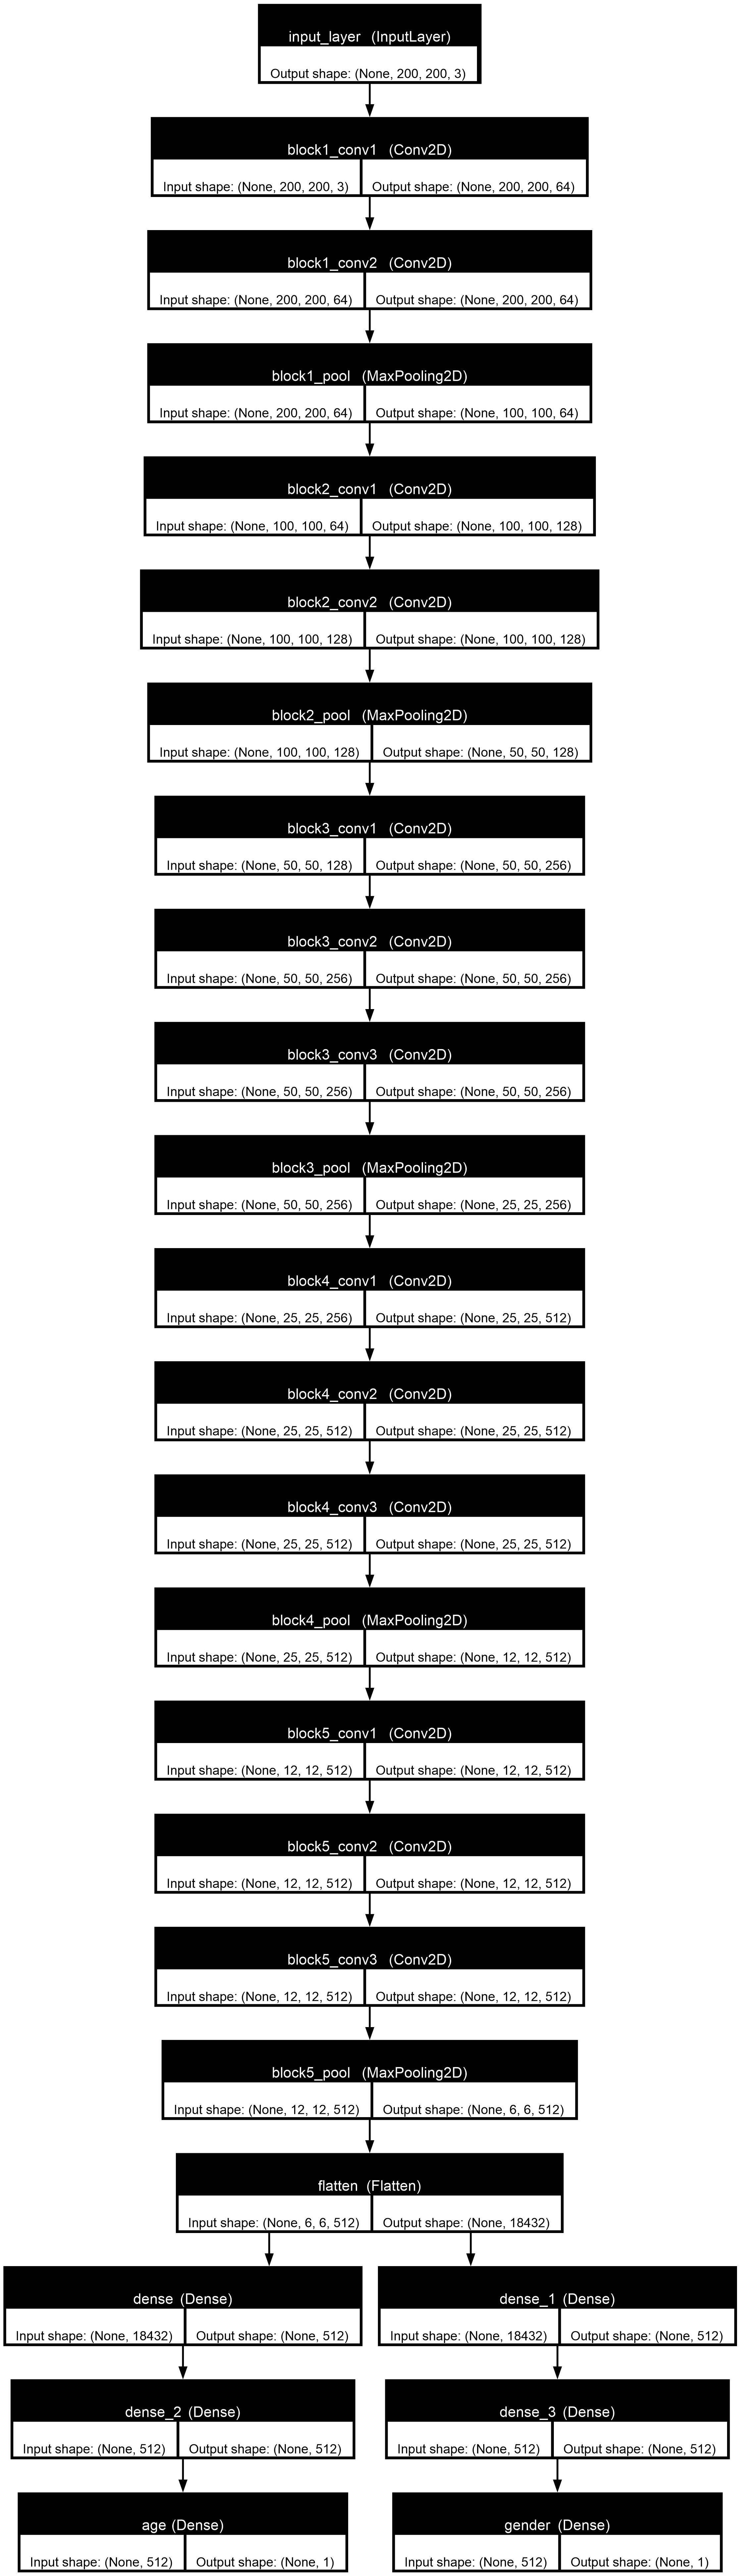

In [6]:
from keras.utils import plot_model
plot_model(model, show_shapes=True,show_layer_names=True)

In [14]:
model.compile(optimizer='adam', loss={'age':'mae','gender':'binary_crossentropy'},metrics={'age':'mae','gender':'binary_crossentropy'}, loss_weights={'age':1,"gender":99})

In [15]:
model.fit(train_gen,batch_size=32,epochs=10,validation_data=test_gen)

Epoch 1/10
625/625 [==============================] - 480s 745ms/step - loss: 63.7653 - age_loss: 10.8147 - gender_loss: 0.5349 - age_mae: 10.8147 - gender_binary_crossentropy: 0.5349 - val_loss: 46.8196 - val_age_loss: 8.9305 - val_gender_loss: 0.3827 - val_age_mae: 8.9305 - val_gender_binary_crossentropy: 0.3827
Epoch 2/10
625/625 [==============================] - 174s 279ms/step - loss: 53.5289 - age_loss: 9.3969 - gender_loss: 0.4458 - age_mae: 9.3969 - gender_binary_crossentropy: 0.4458 - val_loss: 41.3826 - val_age_loss: 8.1031 - val_gender_loss: 0.3362 - val_age_mae: 8.1031 - val_gender_binary_crossentropy: 0.3362
Epoch 3/10
625/625 [==============================] - 190s 304ms/step - loss: 50.1623 - age_loss: 9.0598 - gender_loss: 0.4152 - age_mae: 9.0598 - gender_binary_crossentropy: 0.4152 - val_loss: 40.6159 - val_age_loss: 8.9082 - val_gender_loss: 0.3203 - val_age_mae: 8.9082 - val_gender_binary_crossentropy: 0.3203
Epoch 4/10
625/625 [==============================] - 15

### Testing the trained model


In [17]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array


def predict_age_gender(image_path):
    img = load_img(image_path, target_size=(200, 200))
    img_array = img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    age_pred, gender_pred = model.predict(img_array, verbose=0)
    predicted_age = int(round(age_pred[0][0]))
    predicted_gender = "Male" if gender_pred[0][0] >= 0.5 else "Female"

    return predicted_age, float(gender_pred[0][0]), predicted_gender


# Example: test on one image from the dataframe
sample_image_path = os.path.join(folder_path, df["img"].iloc[0])
predicted_age, gender_prob, predicted_gender = predict_age_gender(sample_image_path)
print("Image:", sample_image_path)
print("Predicted age:", predicted_age)
print("Gender probability:", gender_prob)
print("Predicted gender:", predicted_gender)

Image: C:\Users\rauna\codes\datasets\UTKFace\100_0_0_20170112213500903.jpg.chip.jpg
Predicted age: 104
Gender probability: 0.3642728626728058
Predicted gender: Female


In [18]:
# Evaluate on the labeled test generator
results = model.evaluate(test_gen, verbose=0)
print("Test results:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value}")

Test results:
loss: 38.72689437866211
age_loss: 7.426729679107666
gender_loss: 0.31616339087486267
age_mae: 7.426729679107666
gender_binary_crossentropy: 0.31616339087486267
